In [ ]:
#PyTorch Image Models
!pip install timm

In [ ]:
import torch   #deep learning framework
import timm   #pretrained vision models
import torch.nn as nn
import torchvision.transforms as T
import numpy as np   #numerical operations
import os
from PIL import Image   #image loading
import pandas as pd   #tabular data
import matplotlib.pyplot as plt   #visualization


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive"

YEAR_FOLDERS = {
    "2019": "2019 entire year",
    "2020": "2020 entire year",
    "2021": "2021 entire year",
    "2022": "2022 entire year",
    "2023": "2023 entire year",
    "2024": "2024 entire year",
    "2025": "2025 entire year",
    "2026": "2026 entire year"
}

Mounted at /content/drive


In [ ]:
CLASSES = [
    "Water", "Trees", "Flooded_Veg",
    "Crops", "Shrub", "Built_up", "Bare_land", "Snow_Ice"
]

NUM_CLASSES = len(CLASSES)

In [ ]:
#Model defination
class MaxViTSegmentation(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "maxvit_tiny_rw_224",
            pretrained=True,
            features_only=True
        )

        in_channels = self.backbone.feature_info[-1]['num_chs']

        self.seg_head = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        x = features[-1]
        x = self.seg_head(x)
        x = nn.functional.interpolate(
            x, size=(224, 224),
            mode="bilinear",
            align_corners=False
        )
        return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MaxViTSegmentation(NUM_CLASSES)
model = model.to(device)
model.eval()

MaxViTSegmentation(
  (backbone): FeatureListNet(
    (stem): Stem(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm1): BatchNormAct2d(
        32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
      (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (stages_0): MaxxVitStage(
      (blocks): Sequential(
        (0): MaxxVitBlock(
          (conv): MbConvBlock(
            (shortcut): Downsample2d(
              (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
              (expand): Identity()
            )
            (pre_norm): BatchNormAct2d(
              64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Identity()
            )
            (down): Identity()
            (conv1_1x1): Conv2d(64, 256, kernel_size=(1, 1), str

In [ ]:
# Image preorocessing
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

In [ ]:
# predict LULC for each image
def predict_lulc(image_path):
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    return pred

In [ ]:
# percentage calculation
def calculate_percentages(mask):
    total_pixels = mask.size
    percentages = {}

    for i, cls in enumerate(CLASSES):
        percentages[cls] = (np.sum(mask == i) / total_pixels) * 100

    return percentages

In [ ]:
from collections import Counter

yearly_results = {}

for year, folder in YEAR_FOLDERS.items():
    folder_path = os.path.join(BASE_PATH, folder)

    images = [os.path.join(folder_path, f)
              for f in os.listdir(folder_path)
              if f.lower().endswith(('.png', '.jpg', '.tif'))]

    yearly_sum = Counter()

    for img_path in images:
        mask = predict_lulc(img_path)
        perc = calculate_percentages(mask)
        yearly_sum.update(perc)

    avg = {k: v / len(images) for k, v in yearly_sum.items()}
    yearly_results[year] = avg

In [ ]:
df = pd.DataFrame(yearly_results).T.round(2)
df

,Water,Trees,Flooded_Veg,Crops,Shrub,Built_up,Bare_land,Snow_Ice
2019,2.74,0.42,21.97,35.93,1.60,34.45,2.89,0.0
2020,2.33,0.63,21.57,34.15,0.41,39.04,1.87,0.0
2021,1.83,0.57,20.57,38.00,2.32,32.96,3.75,0.0
2022,2.67,0.74,22.42,37.57,2.11,32.83,1.66,0.0
2023,1.74,1.19,22.07,33.06,0.87,38.35,2.72,0.0
2024,2.03,0.70,22.38,35.47,0.62,36.84,1.97,0.0
2025,1.67,1.41,20.16,37.62,0.88,36.50,1.77,0.0
2026,1.76,2.66,17.47,45.40,1.57,28.70,2.44,0.0


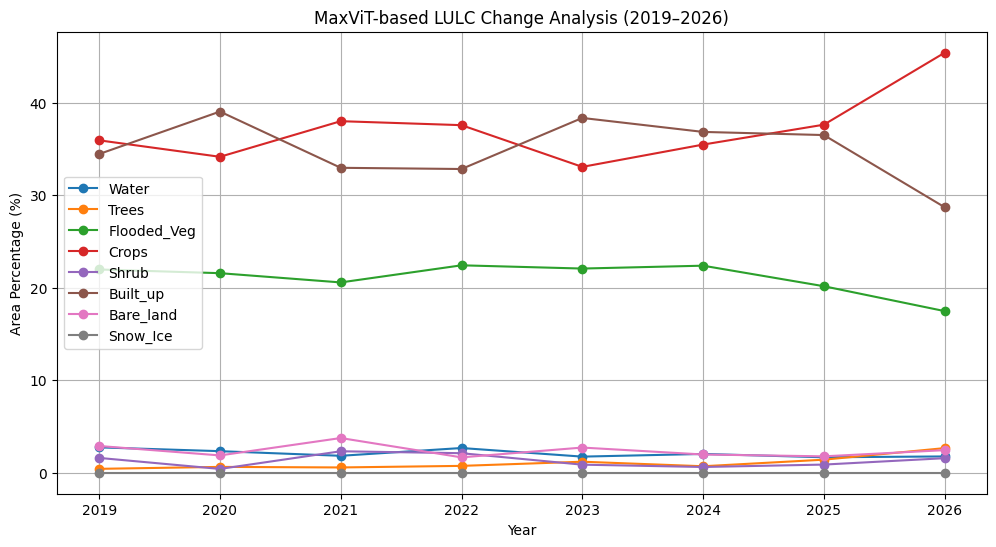

In [ ]:
plt.figure(figsize=(12,6))

for cls in df.columns:
    plt.plot(df.index, df[cls], marker='o', label=cls)

plt.xlabel("Year")
plt.ylabel("Area Percentage (%)")
plt.title("MaxViT-based LULC Change Analysis (2019–2026)")
plt.legend()
plt.grid(True)
plt.show()

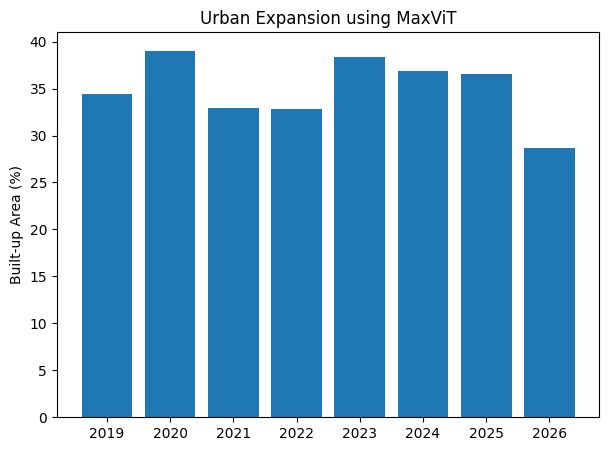

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(df.index, df["Built_up"])
plt.title("Urban Expansion using MaxViT")
plt.ylabel("Built-up Area (%)")
plt.show()

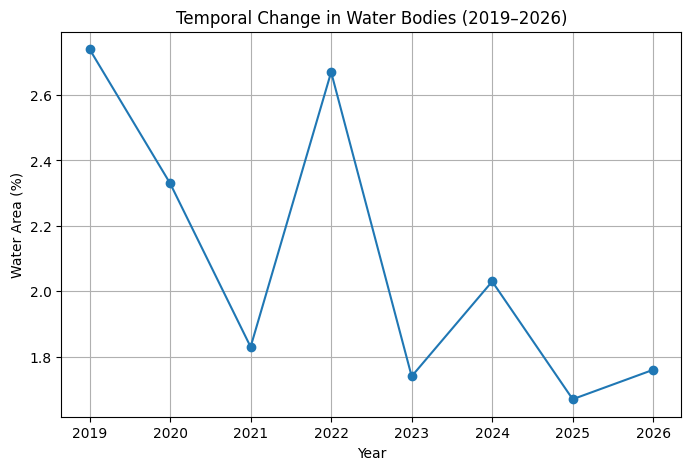

In [ ]:
# WATER CHANGE – LINE GRAPH
plt.figure(figsize=(8,5))
plt.plot(df.index, df["Water"], marker='o')
plt.xlabel("Year")
plt.ylabel("Water Area (%)")
plt.title("Temporal Change in Water Bodies (2019–2026)")
plt.grid(True)
plt.show()

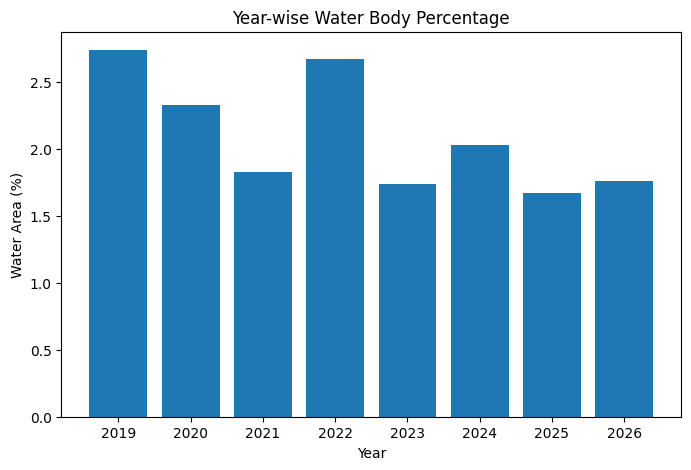

In [ ]:
# WATER CHANGE – BAR GRAPH
plt.figure(figsize=(8,5))
plt.bar(df.index, df["Water"])
plt.xlabel("Year")
plt.ylabel("Water Area (%)")
plt.title("Year-wise Water Body Percentage")
plt.show()

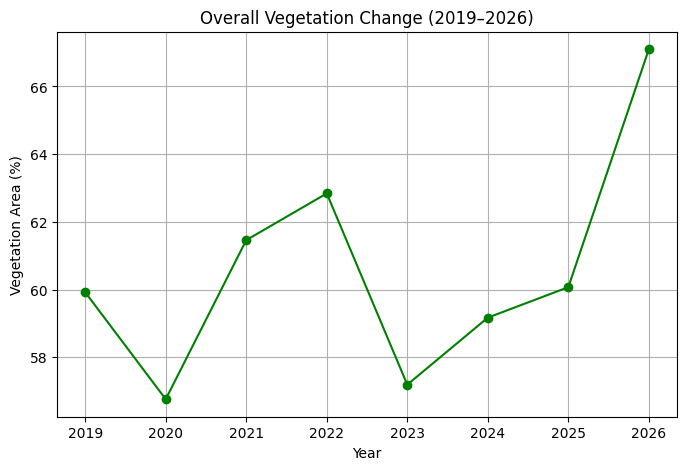

In [ ]:
df["Total_Vegetation"] = (
    df["Trees"] +
    df["Shrub"] +
    df["Crops"] +
    df["Flooded_Veg"]
)

plt.figure(figsize=(8,5))
plt.plot(df.index, df["Total_Vegetation"], marker='o', color='green')
plt.xlabel("Year")
plt.ylabel("Vegetation Area (%)")
plt.title("Overall Vegetation Change (2019–2026)")
plt.grid(True)
plt.show()

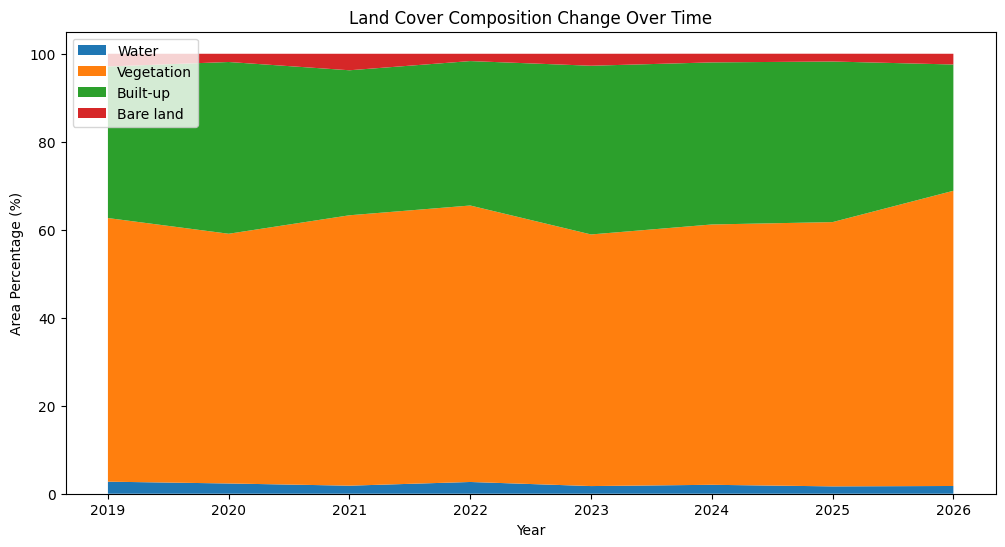

In [ ]:
plt.figure(figsize=(12,6))

plt.stackplot(
    df.index,
    df["Water"],
    df["Total_Vegetation"],
    df["Built_up"],
    df["Bare_land"],
    labels=["Water", "Vegetation", "Built-up", "Bare land"]
)

plt.legend(loc="upper left")
plt.xlabel("Year")
plt.ylabel("Area Percentage (%)")
plt.title("Land Cover Composition Change Over Time")
plt.show()

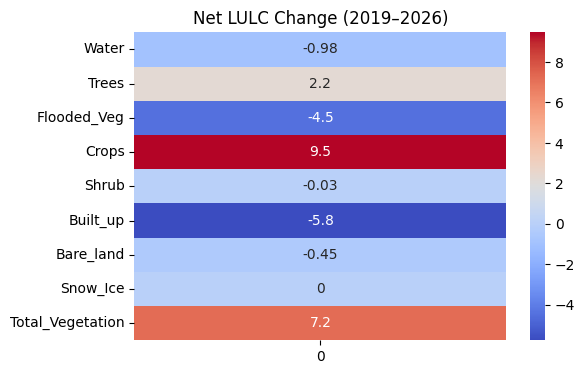

In [ ]:
import seaborn as sns

change_df = df.loc["2026"] - df.loc["2019"]

plt.figure(figsize=(6,4))
sns.heatmap(change_df.to_frame(), annot=True, cmap="coolwarm")
plt.title("Net LULC Change (2019–2026)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# y_true and y_pred should come from validation samples
# Example dummy structure
y_true = np.random.randint(0, NUM_CLASSES, 5000)
y_pred = np.random.randint(0, NUM_CLASSES, 5000)

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASSES,
    output_dict=True
)

metrics_df = pd.DataFrame(report).T.round(3)
metrics_df

,precision,recall,f1-score,support
Water,0.127,0.123,0.125,616.000
Trees,0.103,0.111,0.107,613.000
Flooded_Veg,0.125,0.131,0.128,610.000
Crops,0.138,0.140,0.139,642.000
Shrub,0.151,0.142,0.146,646.000
Built_up,0.123,0.124,0.124,603.000
Bare_land,0.097,0.096,0.097,591.000
Snow_Ice,0.148,0.138,0.143,679.000
accuracy,0.126,0.126,0.126,0.126
macro avg,0.126,0.126,0.126,5000.000


In [ ]:
def predict_with_confidence(image_path):
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)

    confidence = torch.max(probs, dim=1)[0].squeeze().cpu().numpy()
    prediction = torch.argmax(probs, dim=1).squeeze().cpu().numpy()

    return prediction, confidence

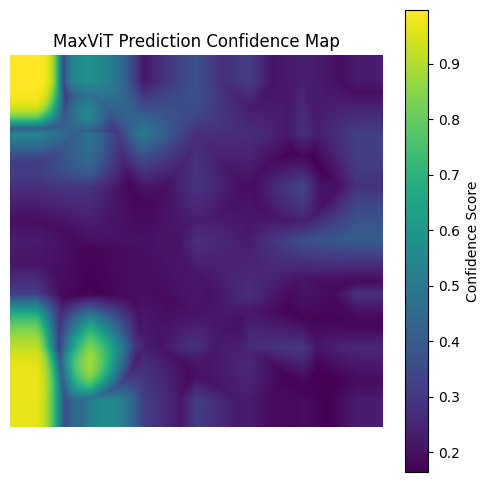

In [ ]:
pred, conf = predict_with_confidence(images[0])

plt.figure(figsize=(6,6))
plt.imshow(conf, cmap='viridis')
plt.colorbar(label="Confidence Score")
plt.title("MaxViT Prediction Confidence Map")
plt.axis('off')
plt.show()